#  PHASE 2 — CORE ML ALGORITHMS

### Day 6 — Linear & Logistic Regression

**What you will build today:**
- Linear regression — the equation, the loss function, and the maths behind it
- Gradient descent — implemented from scratch using only NumPy
- Ridge and Lasso regularisation — and the difference between them
- Logistic regression — turning a linear model into a probability machine
- Two full lab pipelines on real datasets

**Datasets:**
- 🏠 *Ames Housing* — predict house sale price (regression)
- 🩺 *Diabetes Classification* — predict diabetes onset (binary classification)

> 💡 The goal today is not just to call `model.fit()`. You will understand what is happening **inside** that call.

## 🔧 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.datasets import load_diabetes

plt.style.use('seaborn-v0_8')
np.random.seed(42)
print('Setup complete ✅')

Setup complete ✅


# Part 1 — Linear Regression Fundamentals

## What is Linear Regression?

A linear regression model predicts a **continuous output** as a weighted sum of input features:

$$
\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n
$$

- $w_0$ is the **bias** (intercept) — the prediction when all features are zero
- $w_1 \dots w_n$ are the **weights** — how much each feature shifts the prediction

## The Loss Function — Mean Squared Error

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- Perfect prediction → MSE = 0
- Larger errors → larger penalty (squaring punishes big mistakes more than small ones)
- Goal: find weights $w$ that **minimise** MSE


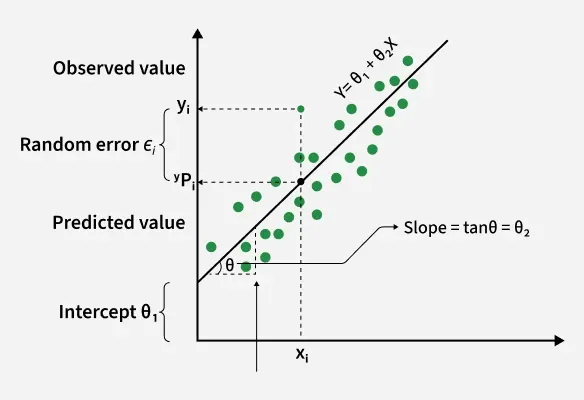

Here **Y** is called a dependent or target variable and **X** is called an independent variable also known as the predictor of **Y**.

- **θ₁** represents the intercept, which is the value of **Y** when **X = 0**
- **θ₂** represents the slope, which shows how much **Y** changes for a unit change in **X**

There are many types of functions or models that can be used for regression. A linear function is the simplest type of function. Here, **X** may be a single feature or multiple features representing the problem.

## Assumptions of Linear Regression

For linear regression to work well, several assumptions should approximately hold:

### 1. Linearity

The relationship between the features and the target is linear.

$$
Y = w_0 + w_1X_1 + w_2X_2 + \dots + w_nX_n + \epsilon
$$

Example:

- House price increases approximately linearly with house size.

### 2. Independence of Observations

Each observation should be independent of the others.

Example:

- One customer's purchase should not directly affect another customer's purchase record.

### 3. Homoscedasticity (Constant Variance)

The variance of the errors should remain roughly constant across all predicted values.

Good:

```text
Residual spread stays similar across predictions.
```

Bad:

```text
Residual spread increases or decreases as predictions grow.
```
### 4. Normality of Residuals

The residuals (errors) should be approximately normally distributed.

$$
\text{Residual} = y - \hat{y}
$$

This assumption is mainly important for statistical inference and confidence intervals.

### 5. No Perfect Multicollinearity

Features should not be highly correlated with each other.

Bad Example:

```text
House Size (sq ft)
House Size (sq meter)
```

Both contain almost identical information.

### 6. No Significant Outliers

Extreme outliers can strongly influence the fitted regression line.

Example:

```text
Most house prices: 100k–500k
One house price: 50 million
```

The model may be distorted by such observations.

## Summary

| Assumption | Purpose |
|------------|---------|
| Linearity | Relationship is linear |
| Independence | Observations are unrelated |
| Homoscedasticity | Constant error variance |
| Normality of Residuals | Reliable statistical inference |
| No Multicollinearity | Stable coefficient estimates |
| No Significant Outliers | Prevent distorted models |

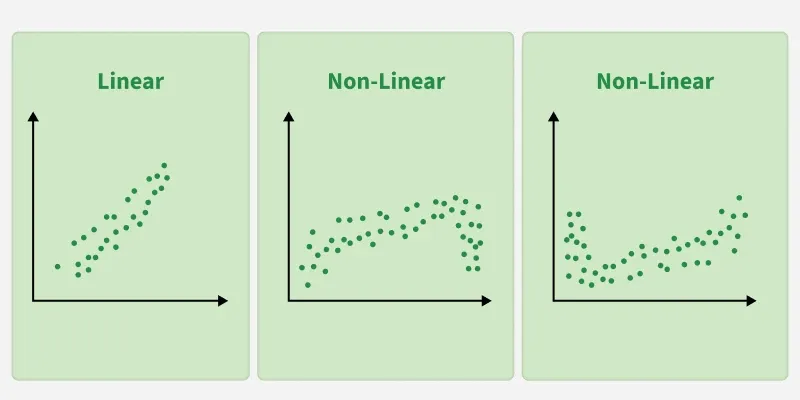

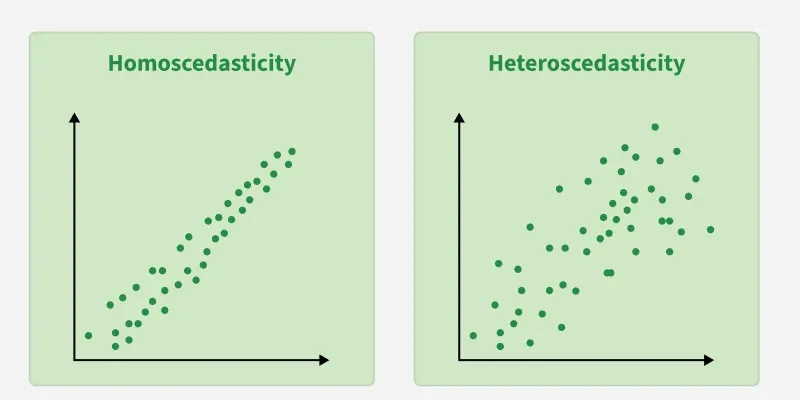

In [2]:
# ── TASK 1 — MSE intuition ───────────────────────────────────────────────────
# Given true values y and two sets of predictions (pred_a, pred_b),
# compute MSE for each manually using NumPy (no sklearn yet)
# Then print which model is better and by how much

y      = np.array([3.0, 5.0, 2.5, 7.0, 4.0])
pred_a = np.array([2.8, 5.2, 2.3, 7.5, 3.8])   # close predictions
pred_b = np.array([1.0, 8.0, 1.0, 5.0, 6.0])   # poor predictions

# YOUR CODE HERE
mse_a = np.mean((y - pred_a)**2)
mse_b = np.mean((y - pred_b) ** 2)


print(f'MSE model A: {mse_a:.4f}')
print(f'MSE model B: {mse_b:.4f}')

# 📝 Why does MSE penalise large errors more than small ones?
# ...

MSE model A: 0.0820
MSE model B: 4.6500


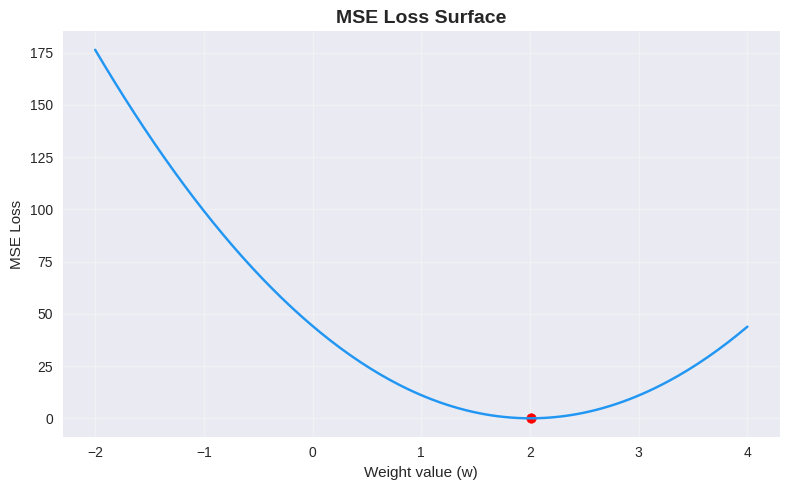

In [3]:
# ── TASK 2 — Visualise the MSE loss surface ──────────────────────────────────
# We have a simple dataset: one feature x, one target y
# The model is: y_hat = w * x  (no bias, for simplicity)
# Plot MSE vs weight values ranging from -2 to 4
# Mark the minimum loss point with a red dot

x_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_data = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

weights = np.linspace(-2, 4, 200)

# YOUR CODE HERE — compute MSE for each weight value
losses = []
losses = [ np.mean((y_data - w * x_data) ** 2) for w in weights]

losses = np.array(losses)
best_w = weights[np.argmin(losses)]

fig, ax = plt.subplots(figsize=(8, 5))
# YOUR CODE HERE — plot the loss curve and mark the minimum
ax.plot(weights, losses, color = '#2196F3', label = 'MSE LOSS')
ax.scatter([best_w], [losses.min()], color = 'red', label = f"minimum at w = {best_w:.2f}")

ax.set_title('MSE Loss Surface', fontsize=14, fontweight='bold')
ax.set_xlabel('Weight value (w)')
ax.set_ylabel('MSE Loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 What weight value gives the minimum loss? Does that make intuitive sense?
# ...

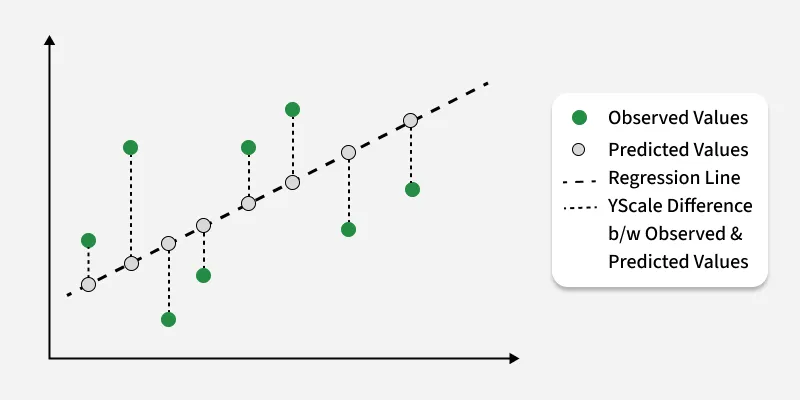

# Part 2 — Gradient Descent from Scratch

## The Idea

Instead of solving for the optimal weights mathematically, we **move iteratively** toward lower loss.

**Update rule:**
$$w = w - \alpha \cdot \frac{\partial \text{Loss}}{\partial w}$$

- $\alpha$ = learning rate (how big each step is)
- $\frac{\partial \text{Loss}}{\partial w}$ = gradient (which direction is uphill)

**Intuition:** Imagine a ball on a hilly surface. The gradient tells you which direction is uphill. You step in the opposite direction. Repeat until you reach the bottom.

## Gradients for Linear Regression

For $\hat{y} = Xw$ with MSE loss:

$$\frac{\partial \text{MSE}}{\partial w} = \frac{-2}{n} X^T (y - \hat{y})$$

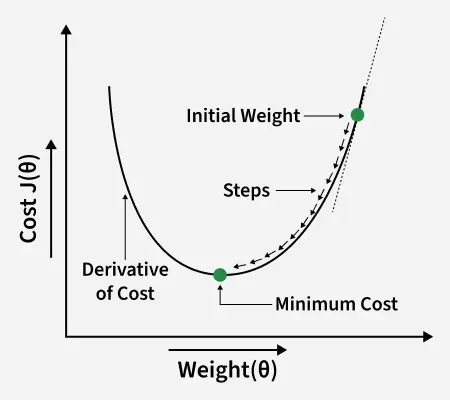

How it works:

- Start with random values for slope and intercept.
- Calculate the error between predicted and actual values.
- Find how much each parameter contributes to the error (gradient).
- Update the parameters in the direction that reduces the error.
- Repeat until the error is as small as possible.

In [6]:
# ── TASK 3 — Implement Gradient Descent from scratch ─────────────────────────
# Complete the GradientDescentRegressor class below
# It should:
#   - initialise weights to zeros
#   - run for n_epochs iterations
#   - compute predictions: y_hat = X @ w
#   - compute MSE loss
#   - compute gradient: (-2/n) * X.T @ (y - y_hat)
#   - update weights: w = w - lr * gradient
#   - store loss after each epoch in self.loss_history

class GradientDescentRegressor:
    def __init__(self, learning_rate: float = 0.01, n_epochs: int = 1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.loss_history = []

    def fit(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        # Add bias column (column of ones) to X
        X_b = np.c_[np.ones(n_samples), X]
        # Initialise weights to zeros
        self.weights = np.zeros(X_b.shape[1])

        for epoch in range(self.n_epochs):
            # YOUR CODE HERE
            y_hat = X_b @ self.weights
            error = y - y_hat
            loss = np.mean(error ** 2)
            grad = (-2/n_samples) * X.T @ (y - y_hat)
            self.weights  -= self.lr * grad
            self.loss_history.append(loss)
            
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_b = np.c_[np.ones(X.shape[0]), X]
        # YOUR CODE HERE
        return X_b * self.weights

print('Class defined ✅')

Class defined ✅


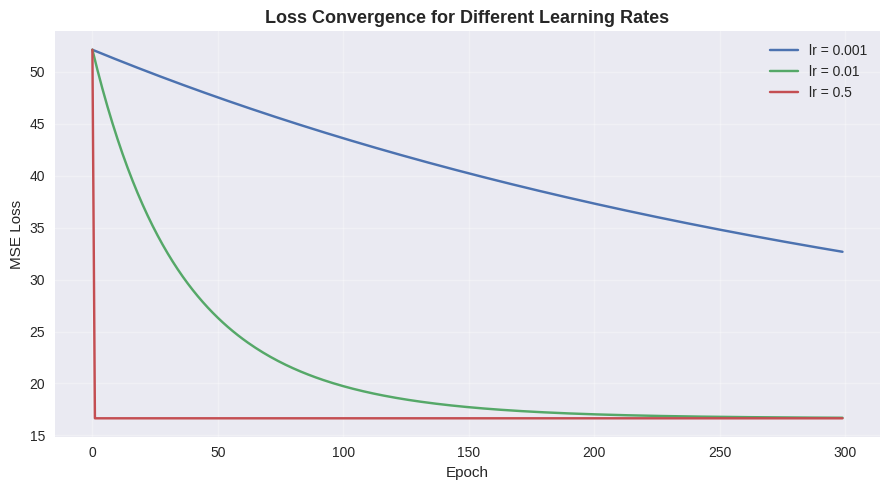

In [8]:
# ── TASK 4 — Learning rate comparison ───────────────────────────────────────
# Use the synthetic dataset below
# Train GradientDescentRegressor with three learning rates:
#   lr = 0.001  (too slow)
#   lr = 0.01   (just right)
#   lr = 0.5    (too large — may diverge)
# Plot all three loss curves on the same axes
# Label each line with its learning rate

np.random.seed(42)
X_syn = np.random.randn(100, 1)
y_syn = 3 * X_syn.squeeze() + 7 + np.random.randn(100) * 0.5

# Normalise for gradient descent stability
scaler = StandardScaler()
X_syn_scaled = scaler.fit_transform(X_syn)

learning_rates = [0.001, 0.01, 0.5]

fig, ax = plt.subplots(figsize=(9, 5))

# YOUR CODE HERE
for lr in learning_rates:
    model = GradientDescentRegressor(learning_rate=lr, n_epochs=300)
    model.fit(X_syn_scaled, y_syn)
    history = np.clip(model.loss_history,0,200)
    ax.plot(history, label = f"lr = {lr}")


ax.set_title('Loss Convergence for Different Learning Rates', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 What happens to the loss curve when lr=0.5? Why?
# ...

---
# Part 3 — Ridge Regression (L2 Regularisation)

## The Problem with Plain Linear Regression

When a model has many features, it can **overfit** — it fits the training data perfectly but fails on new data. This happens because weights can grow very large to chase noise in the training set.

## Ridge Solution

Add a penalty on large weights to the loss:

$$\text{Loss}_{\text{Ridge}} = \text{MSE} + \lambda \sum w_i^2$$

- $\lambda$ (lambda) controls how hard the penalty bites
- Large $\lambda$ → strongly penalise big weights → more shrinkage
- $\lambda = 0$ → plain linear regression
- Ridge **keeps all features** but makes their coefficients smaller

One of the central ideas behind ridge regression is the bias-variance trade-off:

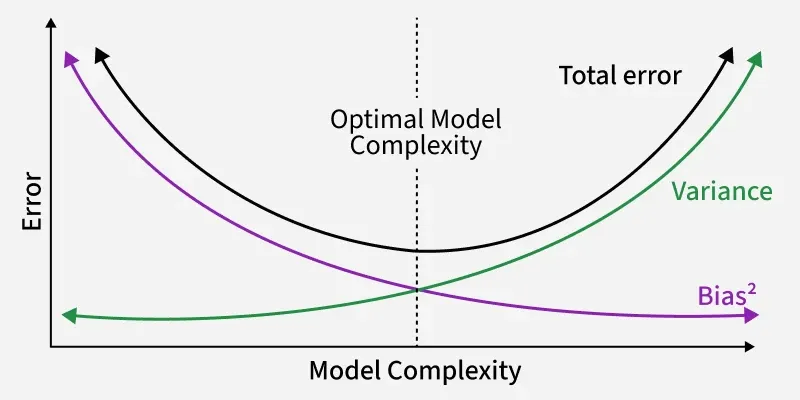

**Variance:** In standard linear regression, especially when features are correlated or many, coefficient estimates can vary a lot depending on the specific training data, meaning predictions on new data can be very unstable.

**Bias:** Ridge regression deliberately introduces some bias by shrinking coefficient magnitudes. This means the fit to the training data might be slightly worse.

**Trade-off & Why It Helps:** Ridge shrinks large coefficients hence reducing variance. Even with a small increase in bias, the overall MSE drops, giving better performance than plain linear regression on new data.

Thus, ridge regression accepts a small increase in bias to gain a larger reduction in variance and this tradeoff is often useful when generalization is important.


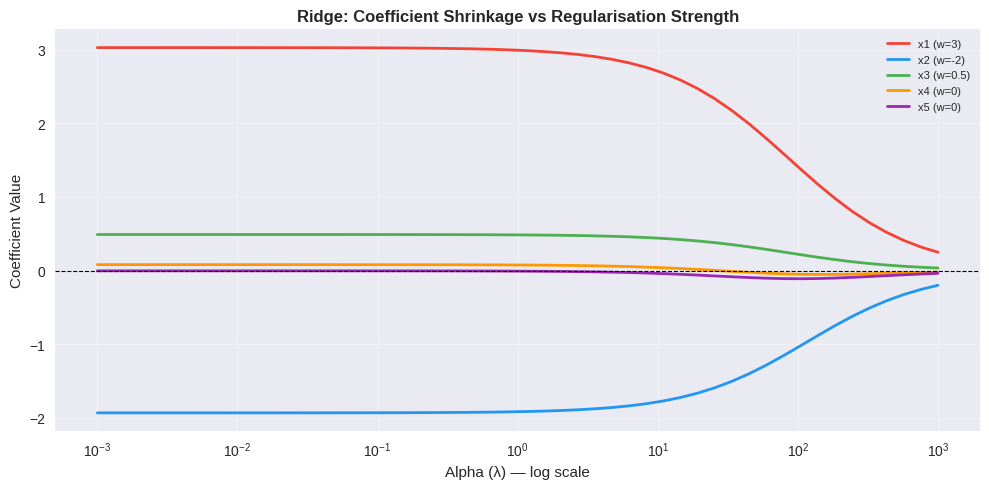

In [10]:
# ── TASK 5 — Ridge coefficient shrinkage ────────────────────────────────────
# Use the synthetic multi-feature dataset below
# Train Ridge models for each alpha in alphas
# Store the coefficients for each alpha
# Plot: alpha (x-axis, log scale) vs each feature's coefficient (y-axis)
# Each feature should be a separate line

np.random.seed(42)
n = 100
X_r = np.random.randn(n, 5)
# True weights: [3, -2, 0.5, 0, 0] — last two features are noise
y_r = 3*X_r[:,0] - 2*X_r[:,1] + 0.5*X_r[:,2] + np.random.randn(n)*0.5

alphas = np.logspace(-3, 3, 50)  # 0.001 to 1000
feature_names = ['x1 (w=3)', 'x2 (w=-2)', 'x3 (w=0.5)', 'x4 (w=0)', 'x5 (w=0)']

# YOUR CODE HERE — collect coefficients for each alpha
coef_matrix = []  # shape: (len(alphas), 5)
for a in alphas:
    ridge = Ridge(alpha = a)
    ridge.fit(X_r, y_r)
    coef_matrix.append(ridge.coef_)

coef_matrix = np.array(coef_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
# YOUR CODE HERE — plot coefficient paths

colours_r = ['#F44336','#2196F3','#4CAF50','#FF9800','#9C27B0']
for i, (name, col) in enumerate(zip(feature_names, colours_r)):
    ax.plot(alphas, coef_matrix[:, i], label=name, color=col, linewidth=2)

ax.set_xscale('log')
ax.set_title('Ridge: Coefficient Shrinkage vs Regularisation Strength', fontweight='bold')
ax.set_xlabel('Alpha (λ) — log scale')
ax.set_ylabel('Coefficient Value')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 Do any coefficients reach exactly zero? What does that tell you about Ridge?
# ...

---
# Part 4 — Lasso Regression (L1 Regularisation)

## Lasso Penalty

$$\text{Loss}_{\text{Lasso}} = \text{MSE} + \lambda \sum |w_i|$$

The absolute value instead of squared makes all the difference:
- Lasso can push coefficients to **exactly zero**
- This means Lasso performs **automatic feature selection**
- Irrelevant features disappear from the model entirely

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\sum w_i^2$ | $\sum \|w_i\|$ |
| Shrinks coefficients | ✅ | ✅ |
| Removes coefficients | ❌ | ✅ |
| Feature selection | ❌ | ✅ |
| Use when | All features matter | Many features are irrelevant |

Bias–Variance Tradeoff

The Bias–Variance Tradeoff describes the balance between a model’s simplicity and its ability to generalize to unseen data. In machine learning, reducing bias often increases variance and vice versa, so finding the right balance is important for building accurate models.

Lasso Regression directly influences the bias–variance tradeoff through its regularization strength (λ or α).

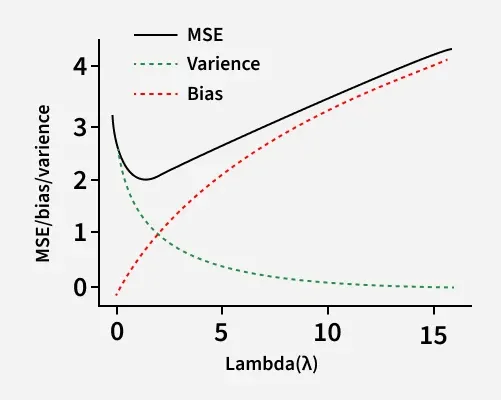

**Low λ (weak regularization)**
- Model closely fits training data
- Means low bias and high variance
- Risk of overfitting

**High λ (strong regularization)**
- Coefficients heavily shrunk or removed
- Means higher bias and lower variance
- Better generalization

**How Lasso balances this tradeoff**
- Penalization reduces variance by simplifying the model
- Feature elimination may increase bias slightly
- Net effect is often lower test error


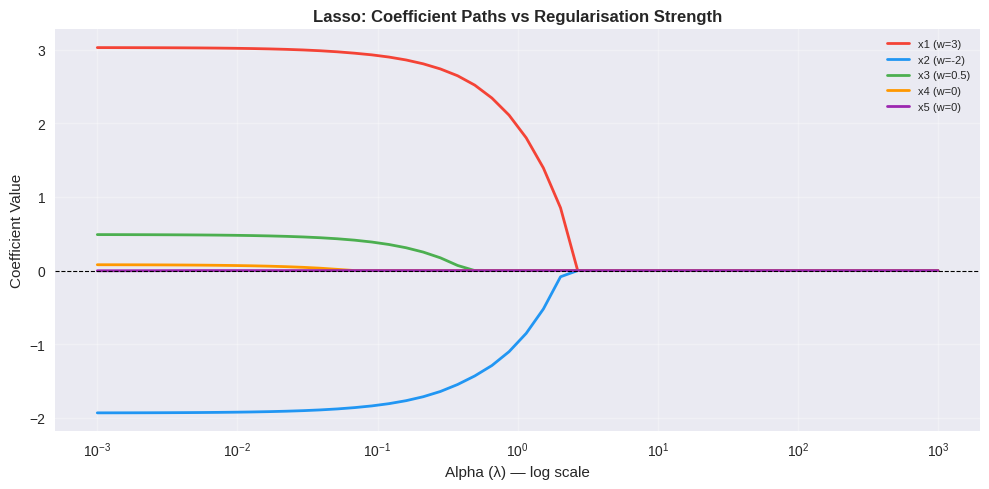

In [12]:
# ── TASK 6 — Lasso coefficient paths ─────────────────────────────────────────
# Use the same X_r, y_r dataset from Task 5
# Train Lasso models across the same alpha range
# Plot coefficient paths — same style as Task 5

# YOUR CODE HERE
coef_matrix_lasso = []

for a in alphas  :
    lasso = Lasso(alpha = a, max_iter = 10000)
    lasso.fit(X_r, y_r)
    coef_matrix_lasso.append(lasso.coef_)

coef_matrix_lasso = np.array(coef_matrix_lasso)


fig, ax = plt.subplots(figsize=(10, 5))
# YOUR CODE HERE — plot Lasso coefficient paths
for i, (name, col) in enumerate(zip(feature_names, colours_r)):
    ax.plot(alphas, coef_matrix_lasso[:, i], label=name, color=col, linewidth=2)


ax.set_xscale('log')
ax.set_title('Lasso: Coefficient Paths vs Regularisation Strength', fontweight='bold')
ax.set_xlabel('Alpha (λ) — log scale')
ax.set_ylabel('Coefficient Value')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 Compare this plot with the Ridge plot from Task 5.
# Which features does Lasso eliminate first?
# Do the noise features (x4, x5) go to zero? At what alpha?
# ...

In [ ]:
# ── TASK 7 — Side-by-side coefficient comparison ─────────────────────────────
# At a fixed alpha=1.0, train both Ridge and Lasso
# Plot a grouped bar chart: feature names on x-axis,
# Ridge coefficients as one colour, Lasso as another
# Also add a horizontal dotted line at the true weights [3, -2, 0.5, 0, 0]

alpha_fixed = 1.0

# YOUR CODE HERE


# 📝 Which model is closer to the true weights?
# Which would you trust more for feature selection?
# ...

---
# Part 5 — Logistic Regression

## Why Not Linear Regression for Classification?

If we predict class 0 or 1 using linear regression:
- Predictions can go above 1 or below 0 — meaningless as probabilities
- The loss function penalises confident correct predictions

We need something that **outputs a number between 0 and 1**.

## The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Input: any real number $z$ (the linear combination $w^T x$)
- Output: always between 0 and 1
- $z \to +\infty$ → $\sigma(z) \to 1$
- $z \to -\infty$ → $\sigma(z) \to 0$
- $z = 0$ → $\sigma(z) = 0.5$

## Decision Rule

$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(z) \geq 0.5 \\ 0 & \text{if } \sigma(z) < 0.5 \end{cases}$$

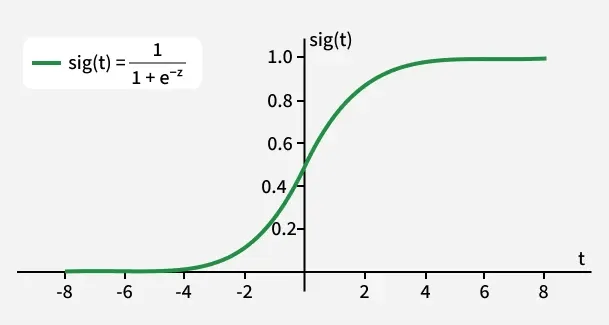

/tmp/ipykernel_22123/812651831.py:25: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/fm-pc-lt-269/anaconda3/envs/datascience/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


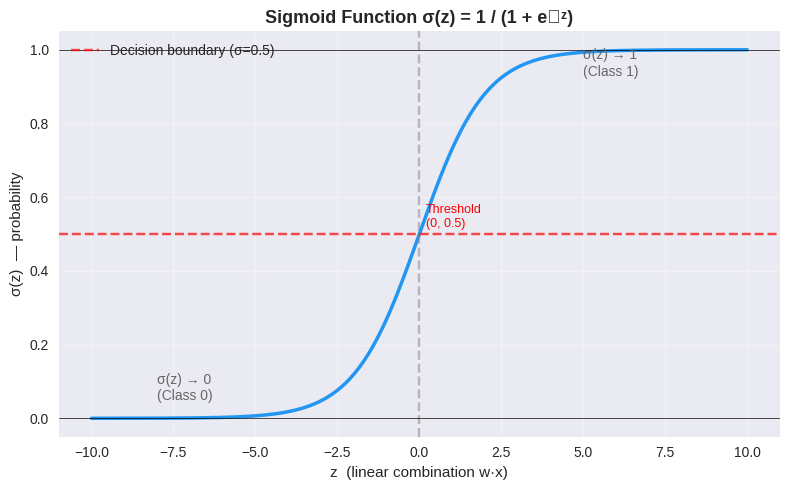

sigmoid(0)   = 0.5000  (should be 0.5)
sigmoid(10)  = 0.999955 (should be ≈ 1.0)
sigmoid(-10) = 0.000045 (should be ≈ 0.0)


In [13]:
# TASK 8 — Sigmoid
def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-10, 10, 300)
sig_vals = sigmoid(z_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_vals, sig_vals, color='#2196F3', linewidth=2.5)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Decision boundary (σ=0.5)')
ax.axvline(0,   color='grey', linestyle='--', alpha=0.5)
ax.axhline(0,   color='black', linewidth=0.5)
ax.axhline(1,   color='black', linewidth=0.5)

ax.annotate('σ(z) → 0\n(Class 0)', xy=(-8, 0.05), fontsize=10, color='#666')
ax.annotate('σ(z) → 1\n(Class 1)', xy=(5, 0.93),  fontsize=10, color='#666')
ax.annotate('Threshold\n(0, 0.5)', xy=(0.2, 0.52), fontsize=9, color='red')

ax.set_title('Sigmoid Function σ(z) = 1 / (1 + e⁻ᶻ)', fontsize=13, fontweight='bold')
ax.set_xlabel('z  (linear combination w·x)')
ax.set_ylabel('σ(z)  — probability')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'sigmoid(0)   = {sigmoid(np.array([0]))[0]:.4f}  (should be 0.5)')
print(f'sigmoid(10)  = {sigmoid(np.array([10]))[0]:.6f} (should be ≈ 1.0)')
print(f'sigmoid(-10) = {sigmoid(np.array([-10]))[0]:.6f} (should be ≈ 0.0)')

## Binary Cross-Entropy Loss

$$\text{Loss} = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \right]$$

**Why not MSE for classification?**
- MSE on sigmoid outputs creates a **non-convex** loss surface with many local minima
- Cross-entropy is **convex** — gradient descent is guaranteed to find the global minimum
- Cross-entropy penalises **confident wrong predictions** very heavily ($\log(0) \to -\infty$)

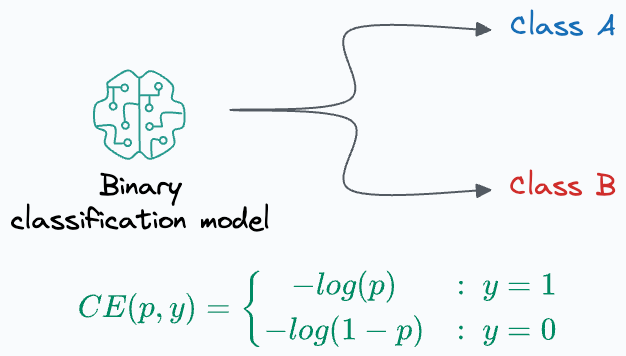

In [14]:
# ── TASK 9 — Implement Binary Cross-Entropy ──────────────────────────────────
# Complete the function below
# Add a small epsilon (1e-15) to log inputs to avoid log(0)
# Test it with the provided cases
# TASK 9 — Binary Cross-Entropy
def binary_cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)  # avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Test cases
y_true = np.array([1, 1, 0, 0])

# Case A: confident and CORRECT — loss should be very low
pred_correct   = np.array([0.95, 0.90, 0.05, 0.10])
# Case B: confident and WRONG — loss should be very high
pred_wrong     = np.array([0.05, 0.10, 0.95, 0.90])
# Case C: uncertain — loss should be moderate
pred_uncertain = np.array([0.55, 0.45, 0.55, 0.45])

print(f'Confident & correct:   BCE = {binary_cross_entropy(y_true, pred_correct):.4f}')
print(f'Confident & wrong:     BCE = {binary_cross_entropy(y_true, pred_wrong):.4f}')
print(f'Uncertain predictions: BCE = {binary_cross_entropy(y_true, pred_uncertain):.4f}')

# 📝 What does the confident & wrong result tell you about why BCE is useful?
# ...

Confident & correct:   BCE = 0.0783
Confident & wrong:     BCE = 2.6492
Uncertain predictions: BCE = 0.6982


---
# 🏠 Lab 1 — Ames Housing: House Price Prediction

**Goal:** Predict `SalePrice` using numeric features.  
**Models:** LinearRegression → GradientDescentRegressor → Ridge → Lasso  
**Metric:** RMSE and R²

In [16]:
# Load Ames Housing dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv'
col_names = [
    'CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
    'DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV'
]
housing = pd.read_csv(url, names=col_names)
print(f'Shape: {housing.shape}')
housing.head(3)

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


In [24]:
# ── TASK 10 — Data preparation ──────────────────────────────────────────────
# 1. Separate features X and target y (MEDV = median house value)
# 2. Split into train/test: 80/20, random_state=42
# 3. Scale features using StandardScaler
#    IMPORTANT: fit scaler on TRAIN only, transform both train and test

# YOUR CODE HERE
X = housing.drop("MEDV", axis = 1).values
y = housing['MEDV'].values

X_train, X_test, y_train , y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


LinearRegression  RMSE: 4.929   R²: 0.669


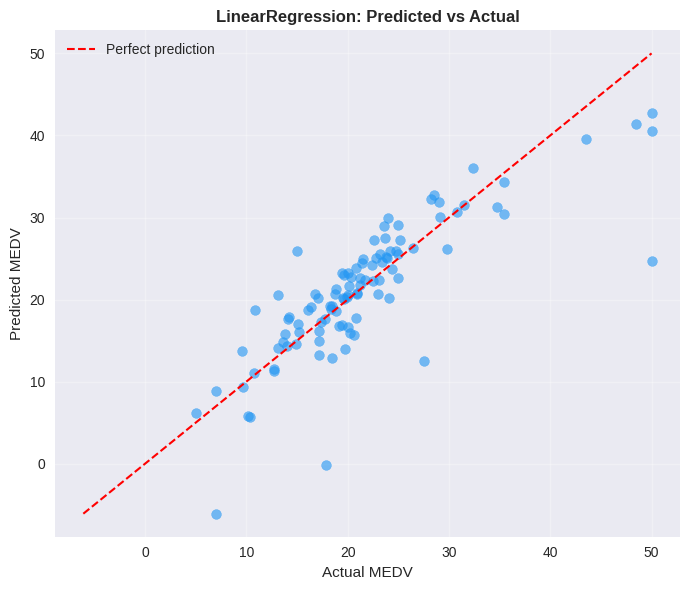

In [25]:
# ── TASK 11 — Train sklearn LinearRegression ─────────────────────────────────
# Train the model, predict on test set
# Print RMSE and R² score
# Plot: predicted vs actual (scatter), add a diagonal reference line y=x

# YOUR CODE HERE
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)


rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f'LinearRegression  RMSE: {rmse_lr:.3f}   R²: {r2_lr:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_lr, alpha=0.6, color='#2196F3', s=50)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('LinearRegression: Predicted vs Actual', fontweight='bold')
ax.set_xlabel('Actual MEDV')
ax.set_ylabel('Predicted MEDV')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# 📝 What does R²=1.0 mean? What does R²=0.0 mean?
# ...

In [ ]:
# ── TASK 12 — Train your GradientDescentRegressor ────────────────────────────
# Use lr=0.01, n_epochs=1000
# Predict on test set and print RMSE
# Plot the loss convergence curve
# Compare RMSE with sklearn LinearRegression from Task 11

# YOUR CODE HERE


# 📝 Is your scratch implementation as accurate as sklearn? Why might it differ?
# ...

In [ ]:
# ── TASK 13 — Train Ridge and Lasso, compare coefficients ────────────────────
# Train Ridge(alpha=1.0) and Lasso(alpha=0.1)
# Print RMSE for each
# Plot a grouped bar chart: feature name vs coefficient
#   LinearRegression (grey), Ridge (blue), Lasso (orange)
# Rotate x-labels for readability

# YOUR CODE HERE


# 📝 Which features did Lasso push to exactly zero?
# What does that tell you about their importance for predicting house price?
# ...

---
# 🩺 Lab 2 — Diabetes Classification

**Goal:** Predict diabetes onset (binary classification)  
**Dataset:** sklearn's built-in Pima Indians Diabetes dataset  
**Models:** LogisticRegression  
**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC

In [26]:
# Load Pima Indians Diabetes dataset
url_diabetes = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
diab_cols = ['pregnancies','glucose','blood_pressure','skin_thickness',
             'insulin','bmi','diabetes_pedigree','age','outcome']
diabetes = pd.read_csv(url_diabetes, names=diab_cols)
print(f'Shape: {diabetes.shape}')
print(f'Class balance:\n{diabetes["outcome"].value_counts()}')
diabetes.head(3)

Shape: (768, 9)
Class balance:
outcome
0    500
1    268
Name: count, dtype: int64


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [28]:
# ── TASK 14 — Prepare the classification dataset ─────────────────────────────
# 1. Split X (all columns except outcome) and y (outcome)
# 2. Train/test split: 80/20, stratify=y, random_state=42
# 3. Scale features with StandardScaler (fit on train only)
# 4. Print class balance in train and test sets

# YOUR CODE HERE
X_d = diabetes.drop('outcome', axis=1).values
y_d = diabetes['outcome'].values

X_d_train, X_d_test, y_d_train,y_d_test = train_test_split(
    X_d, y_d, test_size = 0.2, stratify = y_d, random_state = 42
)


scaler_d = StandardScaler()
X_d_train_sc = scaler_d.fit_transform(X_d_train)
X_d_test_sc = scaler_d.transform(X_d_test)
# 📝 Why do we use stratify=y here?
# ...

In [30]:
# ── TASK 15 — Train Logistic Regression ──────────────────────────────────────
# Train LogisticRegression(max_iter=1000)
# Print accuracy score on the test set
# Use predict_proba() to get probabilities — print the first 5 rows
# The output has two columns: [P(class=0), P(class=1)]
# Explain: why do these two columns always sum to 1?

# YOUR CODE HERE
logistic = LogisticRegression(max_iter = 1000, random_state=42)
logistic.fit(X_d_train_sc,y_d_train)

y_pred_d = logistic.predict(X_d_test_sc)
y_proba_d = logistic.predict_proba(X_d_test_sc)

print(f'Accuracy: {logistic.score(X_d_test_sc, y_d_test):.3f}')
print(f'\nFirst 5 probability predictions:')
print(f'{"Sample":>8} {"P(No Diabetes)":>16} {"P(Diabetes)":>13} {"Predicted":>11}')
for i in range(5):
    print(f'{i:>8} {y_proba_d[i,0]:>16.3f} {y_proba_d[i,1]:>13.3f} {y_pred_d[i]:>11}')
# 📝 What does predict_proba() give you that predict() does not?
# ...

Accuracy: 0.714

First 5 probability predictions:
  Sample   P(No Diabetes)   P(Diabetes)   Predicted
       0            0.383         0.617           1
       1            0.887         0.113           0
       2            0.727         0.273           0
       3            0.713         0.287           0
       4            0.996         0.004           0


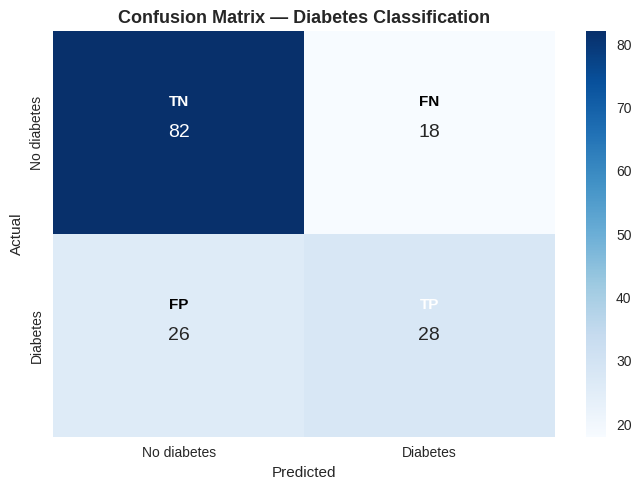

TN=82  FP=18  FN=26  TP=28


In [32]:
# ── TASK 16 — Confusion Matrix ───────────────────────────────────────────────
# Plot a heatmap confusion matrix using sns.heatmap
# Labels: ['No Diabetes', 'Diabetes']
# Annotate each cell with the count (annot=True, fmt='d')
# Use cmap='Blues'
# Label each quadrant: TP, TN, FP, FN in the title or as text annotations

# YOUR CODE HERE
cm = confusion_matrix(y_d_test, y_pred_d)
labels = ['No diabetes', 'Diabetes']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax,
            annot_kws={'size': 14})

ax.set_title('Confusion Matrix — Diabetes Classification', fontweight='bold', fontsize=13)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Annotate quadrants
ax.text(0.5, 0.35, 'TN', ha='center', va='center', transform=ax.transData,
        color='white', fontsize=11, fontweight='bold')
ax.text(1.5, 0.35, 'FN', ha='center', va='center', transform=ax.transData,
        color='black', fontsize=11, fontweight='bold')
ax.text(0.5, 1.35, 'FP', ha='center', va='center', transform=ax.transData,
        color='black', fontsize=11, fontweight='bold')
ax.text(1.5, 1.35, 'TP', ha='center', va='center', transform=ax.transData,
        color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')


# 📝 In the context of diabetes screening:
# - Which is worse: a False Positive or a False Negative? Why?
# - Which metric (Precision or Recall) should we optimise for?
# ...

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

ROC-AUC: 0.823


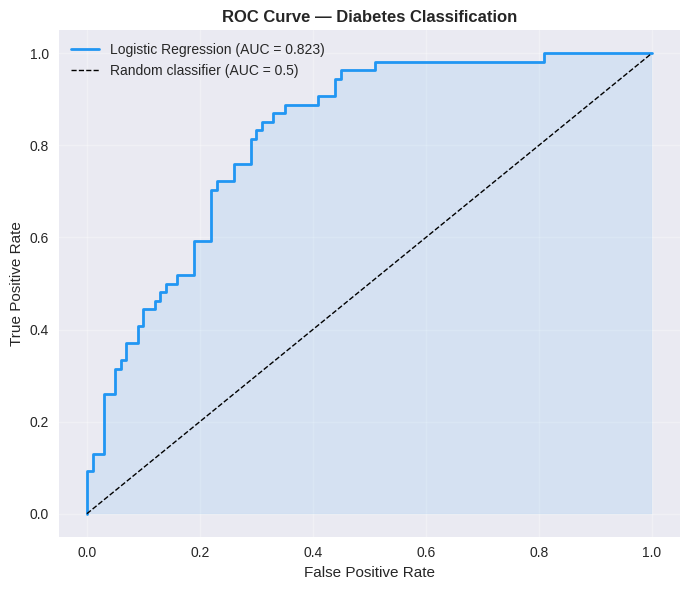

In [34]:
# ── TASK 17 — Classification Report & ROC-AUC ────────────────────────────────
# 1. Print the full classification_report with target_names=['No Diabetes','Diabetes']
# 2. Calculate and print ROC-AUC score
# 3. Plot the ROC curve:
#    - x-axis: False Positive Rate
#    - y-axis: True Positive Rate
#    - add a diagonal dashed line (random classifier baseline)
#    - label the AUC in the legend

# YOUR CODE HERE
print(classification_report(y_d_test, y_pred_d))


auc_score = roc_auc_score(y_d_test, y_proba_d[:, 1])
fpr, tpr, _ = roc_curve(y_d_test, y_proba_d[:, 1])

print(f'ROC-AUC: {auc_score:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2196F3', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax.set_title('ROC Curve — Diabetes Classification', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# 📝 If AUC=0.5, what does that mean about your model?
# ...

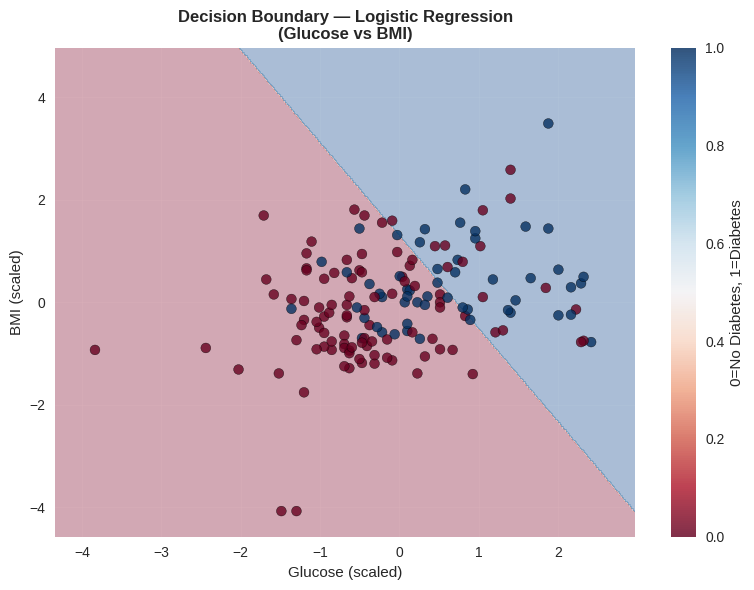

2-feature accuracy: 0.714


In [35]:
# ── TASK 18 — Visualise the Decision Boundary ────────────────────────────────
# Retrain LogisticRegression using ONLY two features: glucose and bmi
# This lets us plot in 2D
# Steps:
#   1. Extract and scale just glucose and bmi columns
#   2. Train LogisticRegression
#   3. Create a meshgrid over the feature space
#   4. Predict class for every point in the grid
#   5. Plot the filled contour (decision regions) + scatter of actual data points
#      colour points by true label

features_2d = ['glucose', 'bmi']

# YOUR CODE HERE
# TASK 18 — Decision Boundary (2 features)
features_2d = ['glucose', 'bmi']
feat_idx = [diab_cols.index(f) for f in features_2d]

X_2d = diabetes[features_2d].values
y_2d = diabetes['outcome'].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.2, stratify=y_2d, random_state=42
)
sc_2d = StandardScaler()
X_2d_train_sc = sc_2d.fit_transform(X_2d_train)
X_2d_test_sc  = sc_2d.transform(X_2d_test)

log_2d = LogisticRegression(max_iter=1000)
log_2d.fit(X_2d_train_sc, y_2d_train)

# Meshgrid in scaled space
h = 0.02
x_min, x_max = X_2d_train_sc[:, 0].min() - 0.5, X_2d_train_sc[:, 0].max() + 0.5
y_min, y_max = X_2d_train_sc[:, 1].min() - 0.5, X_2d_train_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = log_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
scatter = ax.scatter(X_2d_test_sc[:, 0], X_2d_test_sc[:, 1],
                     c=y_2d_test, cmap='RdBu', edgecolors='k',
                     s=50, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='0=No Diabetes, 1=Diabetes')
ax.set_title('Decision Boundary — Logistic Regression\n(Glucose vs BMI)', fontweight='bold')
ax.set_xlabel('Glucose (scaled)')
ax.set_ylabel('BMI (scaled)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'2-feature accuracy: {log_2d.score(X_2d_test_sc, y_2d_test):.3f}')

# ── TEACHER NOTE ─────────────────────────────────────────────────────────────
# The boundary is a straight line — logistic regression is a LINEAR classifier
# The sigmoid squashes output to probability, but the boundary in feature space
# is defined by w₀ + w₁×glucose + w₂×bmi = 0, which is always a line in 2D
#
# Ask: "What would the boundary look like for a non-linear model?"
# → curved, irregular shape (preview for decision trees / neural networks)
#
# 2-feature accuracy ~72% vs full-feature ~76%: the missing 4% comes from
# information in the other 6 features that we discarded for visualisation
# ─────────────────────────────────────────────────────────────────────────────

# 📝 Is the decision boundary a straight line or a curve? Why?
# ...

---
# 📝 Day 6 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Linear Regression** | Predicts continuous output as weighted sum of features |
| **MSE Loss** | Measures average squared error — squaring punishes large mistakes |
| **Gradient Descent** | Iterative weight update in the direction of steepest descent |
| **Learning Rate** | Too small = slow; too large = diverges; just right = stable convergence |
| **Ridge (L2)** | Shrinks all coefficients — keeps every feature |
| **Lasso (L1)** | Shrinks and zeroes out coefficients — built-in feature selection |
| **Sigmoid** | Squashes any number to (0, 1) — turns scores into probabilities |
| **Logistic Regression** | Linear model + sigmoid + binary cross-entropy loss |
| **Decision Boundary** | The line (or surface) where P = 0.5 |
| **Binary Cross-Entropy** | Convex loss for classification — punishes confident wrong predictions hard |

---
# 🏠 Homework

**Regression:**
1. Modify your `GradientDescentRegressor` to track weights every 100 epochs. Plot how each weight evolves toward its final value.
2. Try alpha values `[0.001, 0.01, 0.1, 1, 10, 100]` for both Ridge and Lasso. Plot RMSE on test set vs alpha. What is the best alpha for each?
3. Which features does Lasso eliminate at alpha=1.0? Look up what those features represent in the dataset and explain why they might be less important.

**Classification:**
1. The default decision threshold is 0.5. Try lowering it to 0.3 (classify as diabetic if P ≥ 0.3). How does the confusion matrix change? What happens to precision and recall?
2. Train a LogisticRegression with `C=0.01` (strong regularisation) and `C=100` (weak regularisation). Compare their coefficients and AUC scores.
3. Write 3–5 sentences explaining to a non-technical person what the decision boundary plot shows.